In [ ]:
#LOAD DATASET

from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np

print("Setup Successful")

Setup Successful


In [ ]:
#DATASET SHAPE

df.shape

(9994, 21)

In [ ]:
#COLUMN NAMES, INFO
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

print(df.head())
print(df.info())
print(df.describe())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  06-12-2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [ ]:
#MISSING VALUES

print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
#TOTAL SALES
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2297200.8603000003


In [ ]:
#TOTAL PROFIT
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 286397.0217


In [ ]:
#TOTAL ORDERS
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


In [ ]:
#TOTAL CUSTOMERS
total_customers = df['Customer ID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


In [ ]:
#AVERAGE ORDER VALUE
avg_order_value = total_sales / total_orders
print("Average Order Value:", avg_order_value)

Average Order Value: 458.61466566180883


In [ ]:
#SALES BY REGION
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


In [ ]:
#PROFIT BY CATEGORY
profit_category = df.groupby('Category')['Profit'].sum()

print(profit_category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [ ]:
#Create Year and Month Columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

In [ ]:
#Monthly Sales Trend
monthly_sales = df.groupby('Order Date')['Sales'].sum()
monthly_sales.head()

,Sales
Order Date,
2014-01-03,16.448
2014-01-04,288.060
2014-01-05,19.536
2014-01-06,4407.100
2014-01-07,87.158


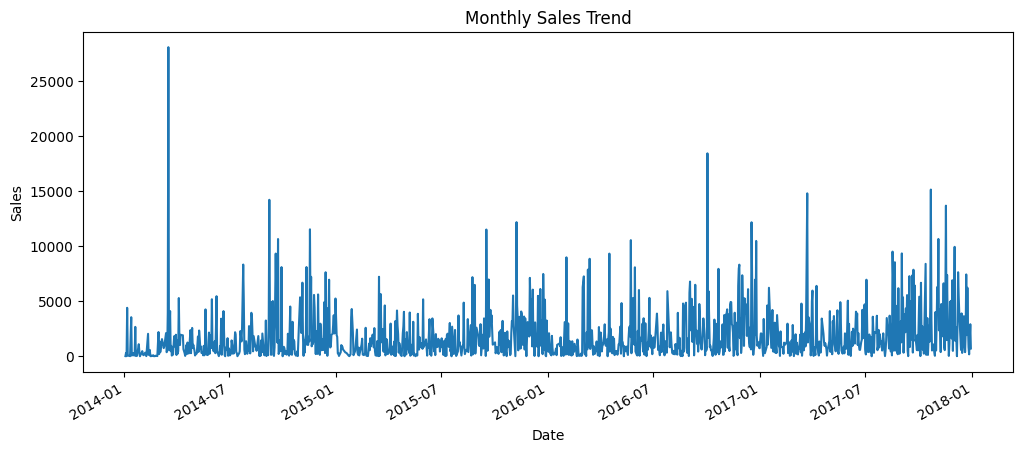

In [ ]:
#PLOT MONTHLY SALES TREND
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(12,5))

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [ ]:
#YEAR WISE SALES
yearly_sales = df.groupby('Year')['Sales'].sum()

print(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


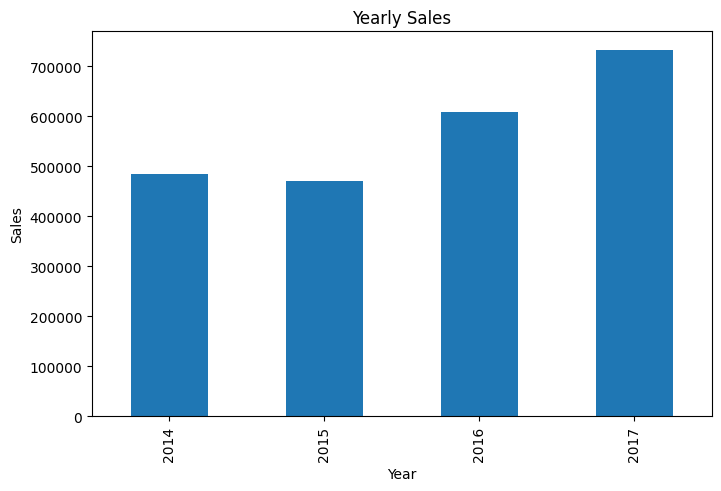

In [ ]:
#PLOT YEAR-WISE SALES
yearly_sales.plot(kind='bar', figsize=(8,5))

plt.title('Yearly Sales')
plt.ylabel('Sales')
plt.show()

In [ ]:
yearly_sales = df.groupby('Year')['Sales'].sum()
print(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


In [ ]:
#TOP PRODUCT ANALYSIS
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


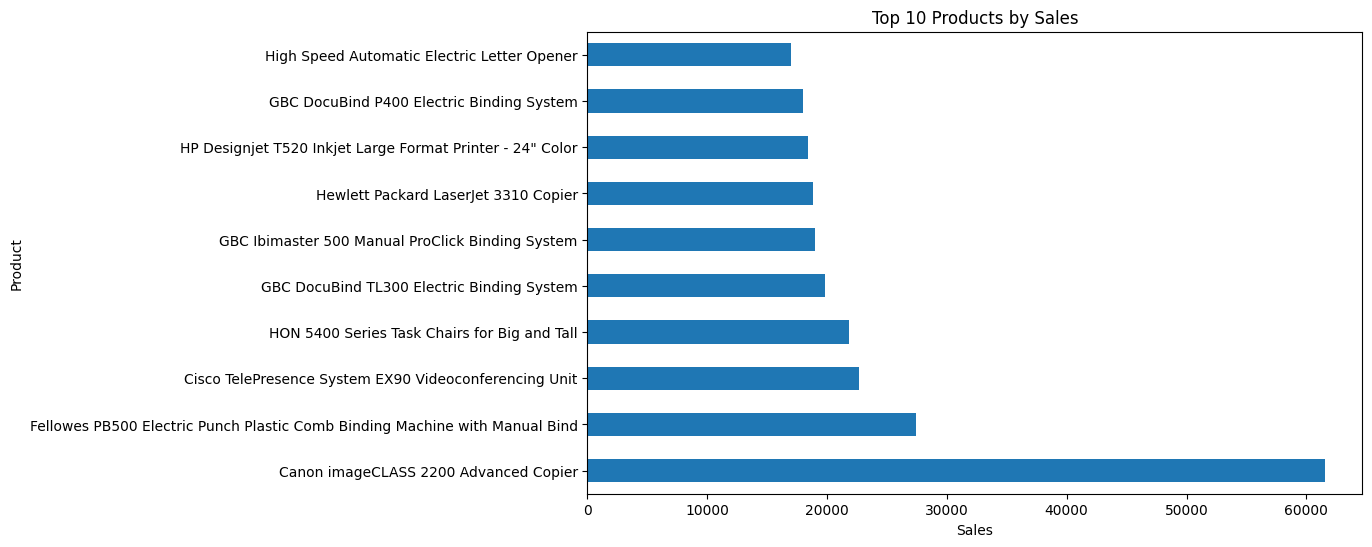

In [ ]:
#BAR CHART
import matplotlib.pyplot as plt

top_products.plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

In [ ]:
#TOP 10 PRODUCTS BY PROFIT
top_profit_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


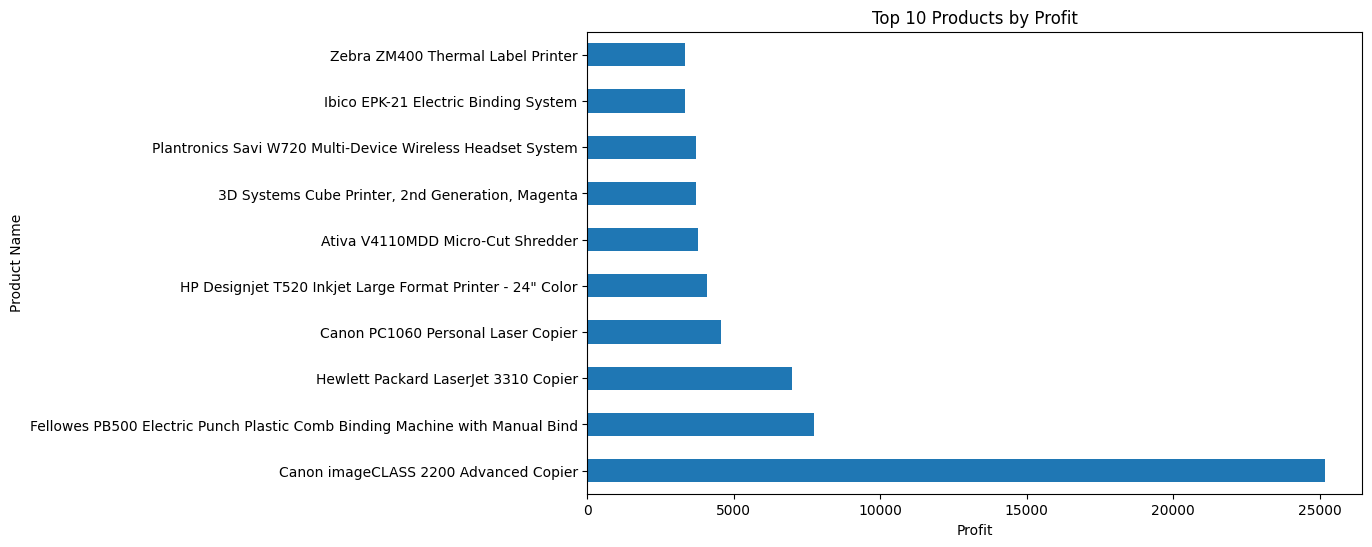

In [ ]:
#PROFIT CHART
top_profit_products.plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.show()

In [ ]:
#CATEGORY SALES
category_sales = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


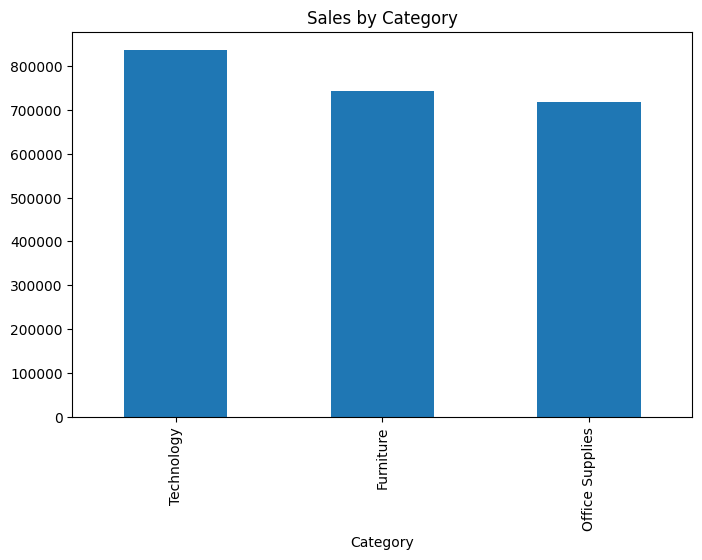

In [ ]:
#CATEGORY SALES CHART
category_sales.plot(
    kind='bar',
    figsize=(8,5),
    title='Sales by Category'
)

plt.show()

In [ ]:
#SUB-CATEGORY SALES
subcat_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

subcat_sales.head(10)

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


In [ ]:
#SUB-CATEGORY PROFIT
subcat_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

subcat_profit.head(10)

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


In [ ]:
#MOST LOSS-MAKING SUB CATEGORIES
subcat_profit.tail(5)

,Profit
Sub-Category,
Machines,3384.7569
Fasteners,949.5182
Supplies,-1189.0995
Bookcases,-3472.5560
Tables,-17725.4811
